Ensemble Learning on Tabular Data with
Categorical Columns

In this notebook we will use a different and very common kind of data: a table with rows and columns, where many of the columns are categories (words like "married" or "student") instead of numbers.

Our goal is the same idea as before. We build five models and compare them:

1. Logistic Regression (this is our baseline model)
2. Random Forest
3. XGBoost
4. LightGBM
5. CatBoost

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier 
from catboost import CatBoostClassifier

In [2]:
bank = pd.read_csv('bank-additional-full.csv', sep=";")
print(bank.shape)

(41188, 21)


In [3]:
bank.head(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
target_counts = bank['y'].value_counts()
print(target_counts)

y
no     36548
yes     4640
Name: count, dtype: int64


Text(0, 0.5, 'Number of customers')

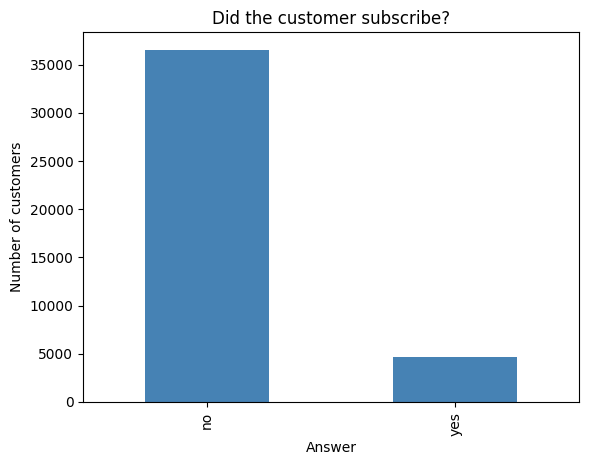

In [5]:
target_counts.plot(kind='bar', color='steelblue')
plt.title("Did the customer subscribe?")
plt.xlabel("Answer")
plt.ylabel("Number of customers")

Data is highly imbalance

In [6]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [7]:
categorical_column = bank.select_dtypes(include='object').columns.to_list()

categorical_column.remove("y")
for i in categorical_column:
    print(i, "=>", bank[i].nunique(), "different values")

job => 12 different values
marital => 4 different values
education => 8 different values
default => 3 different values
housing => 3 different values
loan => 3 different values
contact => 2 different values
month => 10 different values
day_of_week => 5 different values
poutcome => 3 different values


In [8]:
bank = bank.drop(columns=['duration']) #may cause unfair prediction
X_raw = bank.drop(columns=['y']) #data without target column
y_raw = bank['y'] #only the target column

X_encoded = pd.get_dummies(X_raw) #since Logistic reg and random forest do not work with categorical columns

X_native = X_raw.copy() #for XGBoost, LightGBM, CatBoost; copy the data and mark them as category type
for column in categorical_column:
    X_native[column] = X_native[column].astype("category")

Preparing the labels

In [10]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

#0 -> no 
#1 -> yes

Training the data

In [12]:
#version 1, data with one hot encoding
X_enc_train, X_enc_test, y_train, y_test = train_test_split(
    X_encoded, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y 
)

#version 2, data with no one-hot encoding

X_nat_train, X_nat_test, _,_ = train_test_split(
    X_native, y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)
